# Tarea 3 IA – Clasificación de imágenes con CNN (PyTorch)

Este cuadernillo de Jupyter implementa una solución completa para la tarea:
- Organización del dataset en entrenamiento / validación / prueba.
- Definición de una **CNN base**.
- Definición de una **CNN con Dropout**.
- Entrenamiento y validación de ambos modelos.
- Gráficos de `loss` y `accuracy` por época.
- Evaluación final en el conjunto de prueba.

> ⚠️ **Importante:**  
> - Descarga el dataset desde el enlace del curso y guárdalo localmente.  
> - Ajusta la variable `DATA_DIR` más abajo para que apunte a la carpeta donde tengas las imágenes.  
> - Se asume que el dataset está organizado en subcarpetas por clase (formato compatible con `torchvision.datasets.ImageFolder`).

## 1. Importaciones y configuración

Antes de empezar, asegúrate de tener instaladas las siguientes librerías:

```bash
pip install torch torchvision matplotlib scikit-learn
```

Ejecuta las celdas en orden. Si tienes GPU disponible (CUDA), el código la utilizará automáticamente.

In [1]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Subset

from torchvision import datasets, transforms

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import matplotlib.pyplot as plt

# Configuración de dispositivo (GPU si está disponible)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

# Hiperparámetros principales
BATCH_SIZE = 32
LEARNING_RATE = 1e-3
NUM_EPOCHS = 20
RANDOM_SEED = 42

# Fijar semillas para reproducibilidad
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

Usando dispositivo: cpu


## 2. Carga y organización del dataset (train / val / test)

Se asume que el dataset está organizado como:

```text
DATA_DIR/
    clase_0/
        img001.png
        img002.png
        ...
    clase_1/
        ...
    ...
```

Es decir, una carpeta por clase con sus imágenes dentro.  
Ajusta la ruta `DATA_DIR` para apuntar a la carpeta raíz de tu dataset.

In [4]:
# >>>>>>> MODIFICA ESTA RUTA SEGÚN TU ESTRUCTURA <<<<<<
DATA_DIR = "./data/Imagenes"  # ejemplo: "./dataset_t3" o "C:/Users/tu_usuario/dataset_t3"

if not os.path.isdir(DATA_DIR):
    raise FileNotFoundError(
        f"No se encontró la carpeta {DATA_DIR}. "
        "Asegúrate de descargar el dataset y ajustar la ruta."
    )

# Transformaciones: redimensionar a 64x64 y convertir a tensor [0,1]
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

# Cargar dataset completo con ImageFolder
full_dataset = datasets.ImageFolder(root=DATA_DIR, transform=transform)
class_names = full_dataset.classes
num_classes = len(class_names)

print(f"Número total de imágenes: {len(full_dataset)}")
print(f"Clases ({num_classes}): {class_names}")

# Crear índices y etiquetas para dividir estratificadamente
indices = list(range(len(full_dataset)))
labels = full_dataset.targets  # lista de enteros con la clase de cada imagen

# 70% train, 15% val, 15% test
train_idx, temp_idx, y_train, y_temp = train_test_split(
    indices,
    labels,
    test_size=0.30,
    stratify=labels,
    random_state=RANDOM_SEED
)

val_idx, test_idx, y_val, y_test = train_test_split(
    temp_idx,
    y_temp,
    test_size=0.50,       # la mitad para val y la mitad para test
    stratify=y_temp,
    random_state=RANDOM_SEED
)

print(f"Tamaño train: {len(train_idx)}")
print(f"Tamaño val:   {len(val_idx)}")
print(f"Tamaño test:  {len(test_idx)}")

# Crear Subsets
train_dataset = Subset(full_dataset, train_idx)
val_dataset = Subset(full_dataset, val_idx)
test_dataset = Subset(full_dataset, test_idx)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

Número total de imágenes: 15000
Clases (5): ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Residential', 'SeaLake']
Tamaño train: 10500
Tamaño val:   2250
Tamaño test:  2250


## 3. Definición de modelos CNN

Se definen dos modelos:

- `CNN_Base`: modelo convolucional **sin** dropout.
- `CNN_Dropout`: misma arquitectura, pero con una capa `Dropout` antes de la capa fully-connected final.

Ambos modelos asumen imágenes RGB de tamaño 64x64.

In [5]:
class CNN_Base(nn.Module):
    def __init__(self, num_classes: int = 5):
        super(CNN_Base, self).__init__()
        # Capas convolucionales
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Capa fully-connected
        self.fc1 = nn.Linear(in_features=128 * 8 * 8, out_features=128)
        self.fc2 = nn.Linear(in_features=128, out_features=num_classes)

    def forward(self, x):
        # Bloque 1
        x = F.relu(self.conv1(x))
        x = self.pool(x)
        # Bloque 2
        x = F.relu(self.conv2(x))
        x = self.pool(x)
        # Bloque 3
        x = F.relu(self.conv3(x))
        x = self.pool(x)
        # Aplanar
        x = torch.flatten(x, start_dim=1)
        # Fully-connected
        x = F.relu(self.fc1(x))
        x = self.fc2(x)  # logits (CrossEntropyLoss aplica softmax internamente)
        return x


class CNN_Dropout(nn.Module):
    def __init__(self, num_classes: int = 5, p_dropout: float = 0.5):
        super(CNN_Dropout, self).__init__()
        # Capas convolucionales (idénticas a CNN_Base)
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Fully-connected + Dropout
        self.fc1 = nn.Linear(in_features=128 * 8 * 8, out_features=128)
        self.dropout = nn.Dropout(p=p_dropout)
        self.fc2 = nn.Linear(in_features=128, out_features=num_classes)

    def forward(self, x):
        # Bloque 1
        x = F.relu(self.conv1(x))
        x = self.pool(x)
        # Bloque 2
        x = F.relu(self.conv2(x))
        x = self.pool(x)
        # Bloque 3
        x = F.relu(self.conv3(x))
        x = self.pool(x)
        # Aplanar
        x = torch.flatten(x, start_dim=1)
        # Fully-connected + Dropout
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x


# Comprobar que se instancian correctamente
model_base = CNN_Base(num_classes=num_classes).to(device)
model_do = CNN_Dropout(num_classes=num_classes, p_dropout=0.5).to(device)

print(model_base)
print(model_do)

CNN_Base(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=8192, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=5, bias=True)
)
CNN_Dropout(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=8192, out_features=128, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=128, out_features=5, bias=True)
)


## 4. Funciones auxiliares de entrenamiento y evaluación

A continuación se definen funciones para:

- Entrenar un modelo por varias épocas (`train_model`).
- Evaluar un modelo en un `DataLoader` (`evaluate_model`).
- Graficar curvas de `loss` y `accuracy` (`plot_history`).

In [6]:
def train_one_epoch(model, data_loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in data_loader:
        images = images.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc


def evaluate_model(model, data_loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc


def train_model(model, train_loader, val_loader, num_epochs, learning_rate, device):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    
    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": []
    }
    
    for epoch in range(1, num_epochs + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = evaluate_model(model, val_loader, criterion, device)
        
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        
        print(
            f"[Época {epoch:02d}/{num_epochs}] "
            f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}"
        )
    
    return history


def plot_history(history, title_prefix="Modelo"):
    epochs = range(1, len(history["train_loss"]) + 1)
    
    plt.figure(figsize=(12, 5))
    
    # Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history["train_acc"], label="Train Acc")
    plt.plot(epochs, history["val_acc"], label="Val Acc")
    plt.xlabel("Época")
    plt.ylabel("Accuracy")
    plt.title(f"{title_prefix} - Accuracy por época")
    plt.legend()
    
    # Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history["train_loss"], label="Train Loss")
    plt.plot(epochs, history["val_loss"], label="Val Loss")
    plt.xlabel("Época")
    plt.ylabel("Loss")
    plt.title(f"{title_prefix} - Loss por época")
    plt.legend()
    
    plt.tight_layout()
    plt.show()

## 5. Entrenamiento del modelo base (sin Dropout)

Ejecuta la siguiente celda para entrenar el modelo `CNN_Base`.  
Se almacenará el historial de entrenamiento/validación en `history_base`.

In [7]:
# Volver a crear el modelo base fresco (por si ejecutaste antes)
model_base = CNN_Base(num_classes=num_classes).to(device)

print("Entrenando modelo base (sin Dropout)...")
history_base = train_model(
    model=model_base,
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=NUM_EPOCHS,
    learning_rate=LEARNING_RATE,
    device=device
)

Entrenando modelo base (sin Dropout)...
[Época 01/20] Train Loss: 0.7666 | Train Acc: 0.6639 | Val Loss: 0.3909 | Val Acc: 0.8564
[Época 02/20] Train Loss: 0.3613 | Train Acc: 0.8660 | Val Loss: 0.3837 | Val Acc: 0.8529
[Época 03/20] Train Loss: 0.3307 | Train Acc: 0.8765 | Val Loss: 0.4414 | Val Acc: 0.8236
[Época 04/20] Train Loss: 0.2825 | Train Acc: 0.8950 | Val Loss: 0.2414 | Val Acc: 0.9267
[Época 05/20] Train Loss: 0.2326 | Train Acc: 0.9170 | Val Loss: 0.1979 | Val Acc: 0.9382
[Época 06/20] Train Loss: 0.2468 | Train Acc: 0.9106 | Val Loss: 0.2664 | Val Acc: 0.9031
[Época 07/20] Train Loss: 0.2129 | Train Acc: 0.9221 | Val Loss: 0.1864 | Val Acc: 0.9378
[Época 08/20] Train Loss: 0.1675 | Train Acc: 0.9390 | Val Loss: 0.1580 | Val Acc: 0.9458
[Época 09/20] Train Loss: 0.1767 | Train Acc: 0.9340 | Val Loss: 0.1798 | Val Acc: 0.9413
[Época 10/20] Train Loss: 0.1593 | Train Acc: 0.9410 | Val Loss: 0.1855 | Val Acc: 0.9276
[Época 11/20] Train Loss: 0.1504 | Train Acc: 0.9451 | Val L

## 6. Entrenamiento del modelo con Dropout

Ejecuta la siguiente celda para entrenar el modelo `CNN_Dropout`.  
Se almacenará el historial en `history_do`.

In [8]:
# Volver a crear el modelo con Dropout fresco
model_do = CNN_Dropout(num_classes=num_classes, p_dropout=0.5).to(device)

print("Entrenando modelo con Dropout...")
history_do = train_model(
    model=model_do,
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=NUM_EPOCHS,
    learning_rate=LEARNING_RATE,
    device=device
)

Entrenando modelo con Dropout...
[Época 01/20] Train Loss: 0.9151 | Train Acc: 0.5857 | Val Loss: 0.7920 | Val Acc: 0.6729
[Época 02/20] Train Loss: 0.5542 | Train Acc: 0.7956 | Val Loss: 0.4153 | Val Acc: 0.8356
[Época 03/20] Train Loss: 0.3886 | Train Acc: 0.8619 | Val Loss: 0.2970 | Val Acc: 0.8924
[Época 04/20] Train Loss: 0.3572 | Train Acc: 0.8723 | Val Loss: 0.3394 | Val Acc: 0.8818
[Época 05/20] Train Loss: 0.3156 | Train Acc: 0.8883 | Val Loss: 0.2525 | Val Acc: 0.9018
[Época 06/20] Train Loss: 0.2944 | Train Acc: 0.8990 | Val Loss: 0.1894 | Val Acc: 0.9320
[Época 07/20] Train Loss: 0.2350 | Train Acc: 0.9224 | Val Loss: 0.1820 | Val Acc: 0.9404
[Época 08/20] Train Loss: 0.2203 | Train Acc: 0.9221 | Val Loss: 0.2095 | Val Acc: 0.9173
[Época 09/20] Train Loss: 0.2248 | Train Acc: 0.9233 | Val Loss: 0.4946 | Val Acc: 0.8062
[Época 10/20] Train Loss: 0.2112 | Train Acc: 0.9290 | Val Loss: 0.6776 | Val Acc: 0.7733
[Época 11/20] Train Loss: 0.2196 | Train Acc: 0.9271 | Val Loss: 0.

## 7. Gráficas de entrenamiento y validación

Usa las siguientes celdas para visualizar las curvas de `accuracy` y `loss` por época
para ambos modelos (base y con Dropout).

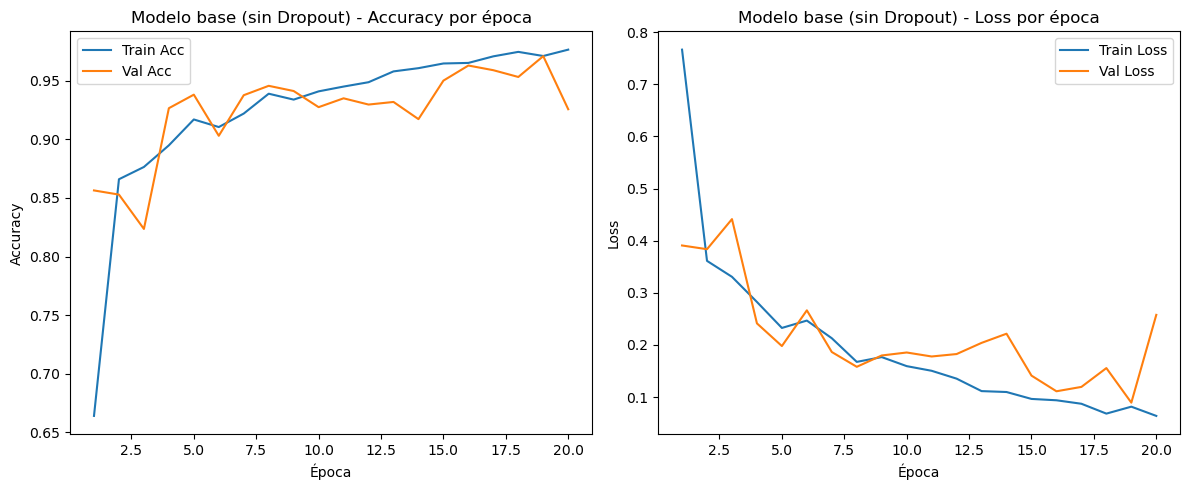

In [9]:
# Curvas del modelo base
plot_history(history_base, title_prefix="Modelo base (sin Dropout)")

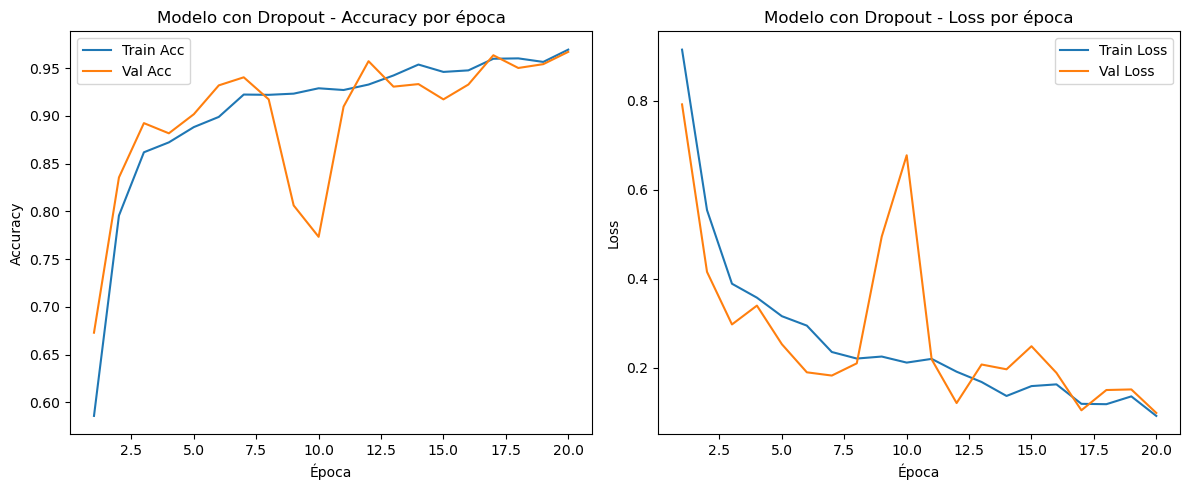

In [10]:
# Curvas del modelo con Dropout
plot_history(history_do, title_prefix="Modelo con Dropout")

## 8. Evaluación en el conjunto de prueba

Finalmente, evaluamos ambos modelos en el conjunto de **prueba**, calculamos:

- `accuracy` final.
- `loss` en prueba.
- `classification_report` (precision, recall, f1 por clase).
- Matriz de confusión.

Esto te servirá de base para el análisis cualitativo en el informe/video (que **no** debe generar IA).

In [11]:
def evaluate_on_test(model, test_loader, device, class_names):
    model.eval()
    criterion = nn.CrossEntropyLoss()
    
    all_labels = []
    all_preds = []
    running_loss = 0.0
    total = 0
    
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            
            all_labels.extend(labels.cpu().numpy().tolist())
            all_preds.extend(preds.cpu().numpy().tolist())
            total += labels.size(0)
    
    test_loss = running_loss / total
    test_acc = (np.array(all_preds) == np.array(all_labels)).mean()
    
    print(f"Test Loss: {test_loss:.4f}")
    print(f"Test Accuracy: {test_acc:.4f}\n")
    
    print("Classification report:")
    print(classification_report(all_labels, all_preds, target_names=class_names))
    
    print("Matriz de confusión:")
    print(confusion_matrix(all_labels, all_preds))


print("\n=== Evaluación modelo base (sin Dropout) ===")
evaluate_on_test(model_base, test_loader, device, class_names)

print("\n=== Evaluación modelo con Dropout ===")
evaluate_on_test(model_do, test_loader, device, class_names)


=== Evaluación modelo base (sin Dropout) ===
Test Loss: 0.2371
Test Accuracy: 0.9258

Classification report:
                      precision    recall  f1-score   support

          AnnualCrop       0.88      0.96      0.92       450
              Forest       0.99      0.87      0.93       450
HerbaceousVegetation       0.94      0.86      0.90       450
         Residential       0.97      0.95      0.96       450
             SeaLake       0.87      0.99      0.93       450

            accuracy                           0.93      2250
           macro avg       0.93      0.93      0.93      2250
        weighted avg       0.93      0.93      0.93      2250

Matriz de confusión:
[[431   0   2   0  17]
 [  7 391   5   0  47]
 [ 45   3 388  11   3]
 [  5   0  19 426   0]
 [  3   0   0   0 447]]

=== Evaluación modelo con Dropout ===
Test Loss: 0.1053
Test Accuracy: 0.9636

Classification report:
                      precision    recall  f1-score   support

          AnnualCrop      